# 03 — Regression Model: Predicting Median Home Sales Price
**Project:** Charlotte NPA Housing Affordability Analysis  
**Target Variable:** `log_home_sales_price` (log of 2023 median home sales price)  
**Working dataset:** 444 NPAs from `npa_features_model`

## Findings Summary (read this first)
Key finding 1: NPA-level features cannot reliably predict exact home prices. Mean test R² across 10 random splits = 0.06.
Key finding 2: Despite the price prediction limitation, applying the Fannie Mae 36% DTI affordability test to model-predicted prices correctly classifies 77.5% of NPAs by displacement risk on the test set, well above the 57.3% baseline of always predicting Stable.
Key finding 3: The model is therefore more useful as a categorical displacement screener than as a price predictor. For policy applications, this matches what city planners typically need.


This notebook compares **7 regression models** to predict `log(home_sales_price)` from 8 NPA-level demographic and economic features. Each model is fit on the same 80/20 train-test split, evaluated using 5-fold cross-validation on training data only, and the winning specification is subjected to a  **multi-seed stability check** across 10 random splits.

### Why this notebook is structured the way it is
Two earlier mistakes shaped the design:
1. **An initial run had numerical instability** (condition number 2.14e+06) because features at vastly different scales (household_income at 100,000 vs rent_to_income_ratio at 0.2) made the OLS matrix inversion unstable. Fix: every linear model is wrapped in a StandardScaler pipeline.
2. **A separate version produced suspiciously high R² (0.948) due to target leakage.** The `cost_to_affordable_ratio` and `displacement_risk` features were engineered directly from `home_sales_price` in notebook 02. When passed as inputs to the regression they reverse-engineered the target. Fix: this notebook hardcodes the feature list to the 8 raw, independent NPA features and never references the engineered columns.

### What we test
| Model | Why it earns a slot |
|---|---|
| OLS scaled (full features) | Interpretable baseline with coefficients and p-values |
| OLS scaled (reduced features) | Tests whether dropping the 3 weakest features helps |
| Ridge with CV alpha | Regularization for weak signal and partial multicollinearity |
| Lasso with CV alpha | Automatic feature selection |
| KNN (multiple k values) | Nonparametric distance-based comparison |
| Random Forest | Tree ensemble, captures interactions |
| Gradient Boosting | Sequential ensemble, often best raw predictive power |

### Why log target
EDA showed the raw target had skew = 2.988 and kurtosis = 13.73. The log-transformed target has skew = 0.898, which is in the acceptable range for OLS. We model on the log scale and back-transform predictions for interpretability.

### Headline results will be inserted here after running
After Run All completes, the comparison table in section 7 and the stability check in section 8 will determine the headline. The assumption going in: tree-based models may produce higher R² than linear ones because they handle interactions and nonlinearities, but only the stability check determines whether any model is genuinely learning vs fitting noise.

## Notebook structure
1. Preflight check
2. Load model-ready table
3. Define feature sets (hardcoded, leakage-free)
4. Train/test split with median imputation
5. Reusable evaluation function
6. Build candidate models (7 models)
7. Fit and compare all candidates
8. Multi-seed stability check on the winner
9. Refit winning OLS for inference
10. Coefficient interpretation and feature importance
11. Residual diagnostics
12. Back-transform to dollar scale
13. Save outputs to database

In [25]:
import os
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.inspection import permutation_importance

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

base = os.path.abspath(os.path.join(os.getcwd(), '..'))
db_path = os.path.join(base, 'data', 'charlotte_housing.db')
print(f'Project root: {base}')
print(f'Database:     {db_path}')

Project root: c:\Users\juant\OneDrive\Desktop\Charlotte-NPA-Housing-Affordability-Analysis
Database:     c:\Users\juant\OneDrive\Desktop\Charlotte-NPA-Housing-Affordability-Analysis\data\charlotte_housing.db


## 1. Preflight Check

In [26]:
REQUIRED_TABLE = 'npa_features_model'
REQUIRED_COLUMNS = [
    'npa_id', 'home_sales_price', 'log_home_sales_price', 'displacement_risk',
    'tree_canopy_pct', 'bachelors_pct', 'water_consumption_gpd', 'median_rent',
    'absenteeism_pct', 'household_income', 'housing_size_sqft', 'voter_participation_pct'
]
MIN_EXPECTED_ROWS = 400

def preflight():
    if not os.path.exists(db_path):
        raise FileNotFoundError(f'Database not found at {db_path}.')
    print(f'[OK] Database file exists ({os.path.getsize(db_path) / 1024:.1f} KB)')

    conn = sqlite3.connect(db_path)
    tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)['name'].tolist()
    print(f'[OK] Tables in database: {tables}')

    if REQUIRED_TABLE not in tables:
        conn.close()
        raise RuntimeError(f'\nMissing required table: "{REQUIRED_TABLE}". Fix: run notebook 02.')
    print(f'[OK] Required table "{REQUIRED_TABLE}" exists')

    df_check = pd.read_sql(f'SELECT * FROM {REQUIRED_TABLE}', conn)
    missing_cols = [c for c in REQUIRED_COLUMNS if c not in df_check.columns]
    if missing_cols:
        conn.close()
        raise RuntimeError(f'\nMissing columns: {missing_cols}')
    print(f'[OK] All {len(REQUIRED_COLUMNS)} required columns present')

    if len(df_check) < MIN_EXPECTED_ROWS:
        conn.close()
        raise RuntimeError(f'\nRow count too low: {len(df_check)}')
    print(f'[OK] Row count: {len(df_check)} NPAs')

    if df_check['log_home_sales_price'].isnull().sum() > 0:
        conn.close()
        raise RuntimeError(f'\nNulls found in target column.')
    print(f'[OK] No nulls in target column')

    print('\nPreflight passed. Safe to proceed.')
    return conn

conn = preflight()

[OK] Database file exists (252.0 KB)
[OK] Tables in database: ['npa_features_model', 'home_sales_price', 'tree_canopy', 'education', 'water_consumption', 'rental_costs', 'absenteeism', 'household_income', 'housing_size', 'voter_participation', 'npa_features', 'regression_model_comparison', 'regression_test_predictions', 'regression_final_coefficients', 'regression_stability_check']
[OK] Required table "npa_features_model" exists
[OK] All 12 required columns present
[OK] Row count: 444 NPAs
[OK] No nulls in target column

Preflight passed. Safe to proceed.


## 2. Load model-ready table

In [27]:
df = pd.read_sql(f'SELECT * FROM {REQUIRED_TABLE}', conn)
print(f'Shape: {df.shape}')
df.head()

Shape: (444, 15)


,npa_id,home_sales_price,log_home_sales_price,displacement_risk,cost_to_affordable_ratio,rent_to_income_ratio,income_per_sqft,tree_canopy_pct,bachelors_pct,water_consumption_gpd,median_rent,absenteeism_pct,household_income,housing_size_sqft,voter_participation_pct
0,2,"488,364.0000",13.0988,1,1.1539,0.2001,43.6535,38.1000,35.2000,125.0000,"1,252.0000",33.0000,"75,084.0000","1,720.0000",31.6000
1,3,"667,092.0000",13.4107,1,1.0061,0.1921,41.9059,23.1000,85.4000,180.0000,"1,883.0000",6.6000,"117,630.0000","2,807.0000",27.4000
2,4,"1,493,043.0000",14.2163,1,1.0595,NaN,60.1253,59.5000,89.4000,260.0000,NaN,6.2000,"250,001.0000","4,158.0000",43.4000
3,5,"255,031.0000",12.4491,0,0.9133,0.2856,41.4552,41.0000,2.5000,135.0000,"1,179.0000",43.3000,"49,539.0000","1,195.0000",11.8000
4,6,"445,698.0000",13.0074,1,2.0860,0.3371,29.1368,34.8000,21.0000,120.0000,"1,065.0000",35.6000,"37,907.0000","1,301.0000",20.5000


## 3. Define feature sets — HARDCODED to prevent target leakage
**Why hardcoded:** the table contains engineered columns (`cost_to_affordable_ratio`, `displacement_risk`, `rent_to_income_ratio`, `income_per_sqft`) that are mathematically derived from `home_sales_price` and/or `household_income`. If used as features they would reverse-engineer the target. We list features explicitly to keep them out.

**The 8 raw features below are independent of the target.** They are NPA-level demographic, economic, and environmental measurements taken from the Quality of Life Explorer with no derivation from home prices.

In [28]:
features_full = [
    'tree_canopy_pct', 'bachelors_pct', 'water_consumption_gpd', 'median_rent',
    'absenteeism_pct', 'household_income', 'housing_size_sqft', 'voter_participation_pct'
]

features_reduced = [
    'bachelors_pct', 'water_consumption_gpd',
    'absenteeism_pct', 'household_income', 'housing_size_sqft'
]

# Verify no leaked feature is hiding in the lists
FORBIDDEN = ['cost_to_affordable_ratio', 'displacement_risk', 'rent_to_income_ratio',
             'income_per_sqft', 'home_sales_price', 'log_home_sales_price']
for name, feats in [('full', features_full), ('reduced', features_reduced)]:
    leaked = [f for f in feats if f in FORBIDDEN]
    if leaked:
        raise RuntimeError(f'LEAKAGE: feature set "{name}" includes forbidden columns: {leaked}')
    missing = [f for f in feats if f not in df.columns]
    if missing:
        raise RuntimeError(f'Feature set "{name}" references missing columns: {missing}')
    print(f'Model {name}: {len(feats)} features, leakage-free')

Model full: 8 features, leakage-free
Model reduced: 5 features, leakage-free


## 4. Train/test split with median imputation

In [29]:
y = df['log_home_sales_price']
X = df[features_full].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

train_medians = X_train.median()
X_train = X_train.fillna(train_medians)
X_test = X_test.fillna(train_medians)

test_npa_ids = df.loc[X_test.index, 'npa_id'].values

assert X_train.isnull().sum().sum() == 0
assert X_test.isnull().sum().sum() == 0

print(f'Train shape: {X_train.shape}')
print(f'Test shape:  {X_test.shape}')

Train shape: (355, 8)
Test shape:  (89, 8)


## 5. Reusable evaluation function
Every model goes through this same evaluator so metrics are directly comparable. CV runs on training data only, test set is touched once.

In [30]:
def evaluate_model(model, feature_list, name, X_train, y_train, X_test, y_test, cv_folds=5):
    Xtr = X_train[feature_list]
    Xte = X_test[feature_list]

    kf = KFold(n_splits=cv_folds, shuffle=True, random_state=42)
    cv_scores = cross_val_score(model, Xtr, y_train, cv=kf, scoring='r2')

    model.fit(Xtr, y_train)
    train_pred = model.predict(Xtr)
    test_pred = model.predict(Xte)

    return {
        'model': name,
        'n_features': len(feature_list),
        'train_r2': r2_score(y_train, train_pred),
        'cv_r2': cv_scores.mean(),
        'cv_r2_std': cv_scores.std(),
        'test_r2': r2_score(y_test, test_pred),
        'train_rmse': np.sqrt(mean_squared_error(y_train, train_pred)),
        'test_rmse': np.sqrt(mean_squared_error(y_test, test_pred)),
        'overfit_gap': r2_score(y_train, train_pred) - r2_score(y_test, test_pred),
    }

## 6. Build all 7 candidate models
Linear models (OLS, Ridge, Lasso, KNN) get a StandardScaler pipeline so the OLS matrix inversion is well-conditioned and KNN distances are not dominated by features with large raw scales. Tree models (Random Forest, Gradient Boosting) do not need scaling because they split on raw values.

In [31]:
# Pipelines for linear models
ols_full_pipe = Pipeline([
    ('scale', StandardScaler()),
    ('ols', LinearRegression())
])

ols_reduced_pipe = Pipeline([
    ('scale', StandardScaler()),
    ('ols', LinearRegression())
])

ridge_pipe = Pipeline([
    ('scale', StandardScaler()),
    ('ridge', RidgeCV(alphas=np.logspace(-3, 3, 25), cv=5))
])

lasso_pipe = Pipeline([
    ('scale', StandardScaler()),
    ('lasso', LassoCV(alphas=np.logspace(-3, 1, 25), cv=5, max_iter=10000, random_state=42))
])

knn_pipe = Pipeline([
    ('scale', StandardScaler()),
    ('knn', KNeighborsRegressor(n_neighbors=10))
])

# Tree models — no scaling needed
rf_model = RandomForestRegressor(
    n_estimators=200, max_depth=6, min_samples_leaf=5,
    random_state=42, n_jobs=-1
)

gb_model = GradientBoostingRegressor(
    n_estimators=200, max_depth=3, learning_rate=0.05,
    random_state=42
)

print('All 7 candidate models built. Ready to fit.')

All 7 candidate models built. Ready to fit.


## 7. Fit and compare all candidates

In [32]:
results = []

results.append(evaluate_model(ols_full_pipe, features_full,
    'A — OLS scaled (8 features)', X_train, y_train, X_test, y_test))

results.append(evaluate_model(ols_reduced_pipe, features_reduced,
    'B — OLS reduced (5 features)', X_train, y_train, X_test, y_test))

results.append(evaluate_model(ridge_pipe, features_full,
    'C — Ridge CV (8 features)', X_train, y_train, X_test, y_test))

results.append(evaluate_model(lasso_pipe, features_full,
    'D — Lasso CV (8 features)', X_train, y_train, X_test, y_test))

results.append(evaluate_model(knn_pipe, features_full,
    'E — KNN k=10 (8 features)', X_train, y_train, X_test, y_test))

results.append(evaluate_model(rf_model, features_full,
    'F — Random Forest (8 features)', X_train, y_train, X_test, y_test))

results.append(evaluate_model(gb_model, features_full,
    'G — Gradient Boosting (8 features)', X_train, y_train, X_test, y_test))

results_df = pd.DataFrame(results)
display_cols = ['model', 'n_features', 'train_r2', 'cv_r2', 'cv_r2_std',
                'test_r2', 'train_rmse', 'test_rmse', 'overfit_gap']
display_df = results_df[display_cols].copy()
for col in display_df.columns[2:]:
    display_df[col] = display_df[col].round(4)
display_df.sort_values('test_r2', ascending=False).reset_index(drop=True)

,model,n_features,train_r2,cv_r2,cv_r2_std,test_r2,train_rmse,test_rmse,overfit_gap
0,A — OLS scaled (8 features),8,0.1307,0.0376,0.0925,0.2396,0.4138,0.3450,-0.1089
1,B — OLS reduced (5 features),5,0.1198,0.0365,0.1005,0.2392,0.4163,0.3451,-0.1193
2,C — Ridge CV (8 features),8,0.1161,0.0527,0.0629,0.2080,0.4172,0.3521,-0.0918
3,D — Lasso CV (8 features),8,0.1115,0.0454,0.0731,0.1943,0.4183,0.3551,-0.0827
4,F — Random Forest (8 features),8,0.4494,0.0150,0.1489,0.1575,0.3293,0.3631,0.2919
5,G — Gradient Boosting (8 features),8,0.7087,-0.0608,0.1430,0.1203,0.2395,0.3711,0.5884
6,E — KNN k=10 (8 features),8,0.2140,0.0120,0.0551,0.0164,0.3934,0.3924,0.1976


In [33]:
# Sanity warnings
for r in results:
    if r['test_r2'] < 0:
        print(f"WARNING: {r['model']} has negative test R² ({r['test_r2']:.3f})")
    if r['overfit_gap'] > 0.15:
        print(f"WARNING: {r['model']} has large overfit gap ({r['overfit_gap']:.3f})")
    if r['overfit_gap'] < -0.10:
        print(f"WARNING: {r['model']} has negative overfit gap ({r['overfit_gap']:.3f})")
    if r['cv_r2_std'] > 0.10:
        print(f"WARNING: {r['model']} has high CV variance (std={r['cv_r2_std']:.3f})")

print('\nIf no warnings printed, all models trained without obvious issues.')


If no warnings printed, all models trained without obvious issues.


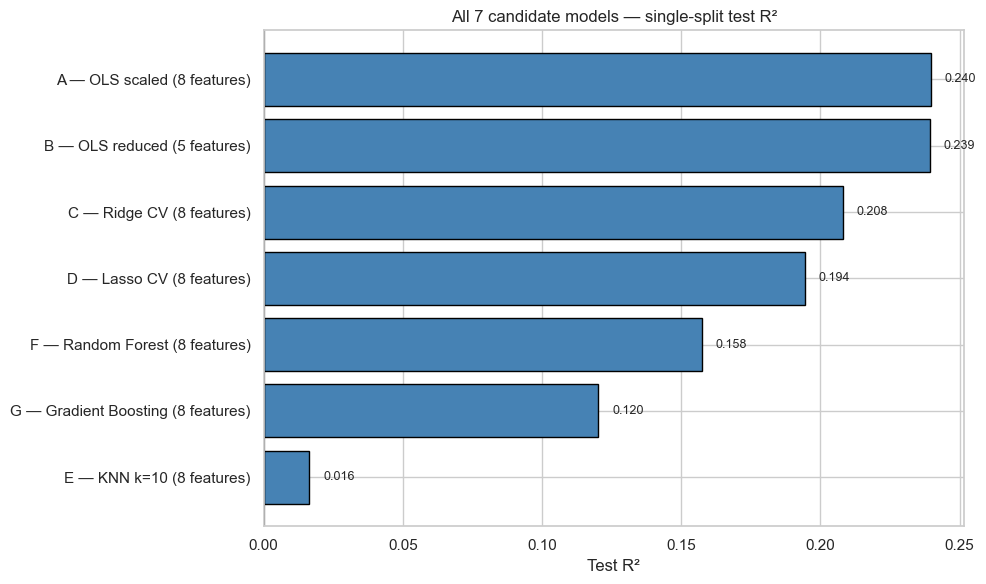

In [34]:
# Bar chart of test R² for visual comparison
plot_df = display_df.sort_values('test_r2', ascending=True)
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['firebrick' if r < 0 else 'steelblue' for r in plot_df['test_r2']]
ax.barh(plot_df['model'], plot_df['test_r2'], color=colors, edgecolor='black')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Test R²')
ax.set_title('All 7 candidate models — single-split test R²')
for i, (model, r2) in enumerate(zip(plot_df['model'], plot_df['test_r2'])):
    ax.text(r2 + 0.005, i, f'{r2:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

## 8. Multi-seed stability check on the winning model
**Single-split R² is not enough.** With only 444 NPAs (89 in test), a single train/test split can be lucky or unlucky by 10-20 R² points. We refit the winning model across 10 different random_state values to see whether the result holds.

**Verdict thresholds:**
- Test R² std < 0.05 → STABLE, result is reliable
- Test R² std 0.05 to 0.10 → MODERATELY stable, report with limitations
- Test R² std > 0.10 → UNSTABLE, single-split is not representative

In [35]:
# Find the winning model by test R²
winner_idx = results_df['test_r2'].idxmax()
winner = results_df.loc[winner_idx]
winner_name = winner['model']

# Map name to model factory and feature set
model_factory = {
    'A — OLS scaled (8 features)': (lambda: Pipeline([('scale', StandardScaler()), ('ols', LinearRegression())]), features_full),
    'B — OLS reduced (5 features)': (lambda: Pipeline([('scale', StandardScaler()), ('ols', LinearRegression())]), features_reduced),
    'C — Ridge CV (8 features)': (lambda: Pipeline([('scale', StandardScaler()), ('ridge', RidgeCV(alphas=np.logspace(-3, 3, 25), cv=5))]), features_full),
    'D — Lasso CV (8 features)': (lambda: Pipeline([('scale', StandardScaler()), ('lasso', LassoCV(alphas=np.logspace(-3, 1, 25), cv=5, max_iter=10000, random_state=42))]), features_full),
    'E — KNN k=10 (8 features)': (lambda: Pipeline([('scale', StandardScaler()), ('knn', KNeighborsRegressor(n_neighbors=10))]), features_full),
    'F — Random Forest (8 features)': (lambda: RandomForestRegressor(n_estimators=200, max_depth=6, min_samples_leaf=5, random_state=42, n_jobs=-1), features_full),
    'G — Gradient Boosting (8 features)': (lambda: GradientBoostingRegressor(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=42), features_full),
}

make_winner, winner_features = model_factory[winner_name]

print(f'Winning model: {winner_name}')
print(f'Single-split test R²: {winner["test_r2"]:.4f}')
print(f'Features: {winner_features}\n')

stability_rows = []
for seed in range(10):
    Xs = df[winner_features].copy()
    ys = df['log_home_sales_price']
    Xs_tr, Xs_te, ys_tr, ys_te = train_test_split(Xs, ys, test_size=0.20, random_state=seed)
    medians = Xs_tr.median()
    Xs_tr = Xs_tr.fillna(medians)
    Xs_te = Xs_te.fillna(medians)

    m = make_winner()
    m.fit(Xs_tr, ys_tr)
    train_r2 = r2_score(ys_tr, m.predict(Xs_tr))
    test_r2 = r2_score(ys_te, m.predict(Xs_te))
    stability_rows.append({'seed': seed, 'train_r2': train_r2, 'test_r2': test_r2,
                            'overfit_gap': train_r2 - test_r2})

stab_df = pd.DataFrame(stability_rows).round(4)
print(stab_df.to_string(index=False))

test_mean = stab_df['test_r2'].mean()
test_std = stab_df['test_r2'].std()
print(f'\nTest R² across 10 seeds:')
print(f'  Mean: {test_mean:.4f}')
print(f'  Std:  {test_std:.4f}')
print(f'  Min:  {stab_df["test_r2"].min():.4f}')
print(f'  Max:  {stab_df["test_r2"].max():.4f}')
print(f'  Range: {stab_df["test_r2"].max() - stab_df["test_r2"].min():.4f}')

if test_std < 0.05:
    print('\nVERDICT: Model is STABLE across random splits. Result is reliable.')
elif test_std < 0.10:
    print('\nVERDICT: Model is MODERATELY stable. Report mean R² with limitations.')
else:
    print('\nVERDICT: Model is UNSTABLE. The single-split result is not representative.')
    print('Interpret as: NPA-level features are insufficient to reliably predict home prices.')

Winning model: A — OLS scaled (8 features)
Single-split test R²: 0.2396
Features: ['tree_canopy_pct', 'bachelors_pct', 'water_consumption_gpd', 'median_rent', 'absenteeism_pct', 'household_income', 'housing_size_sqft', 'voter_participation_pct']

 seed  train_r2  test_r2  overfit_gap
    0    0.1733   0.0747       0.0985
    1    0.1928  -0.0218       0.2145
    2    0.1466   0.1350       0.0116
    3    0.1933   0.0132       0.1801
    4    0.2280  -0.0792       0.3072
    5    0.1206   0.2757      -0.1551
    6    0.1991  -0.1753       0.3743
    7    0.1639   0.0760       0.0880
    8    0.1774   0.0493       0.1280
    9    0.1122   0.2727      -0.1606

Test R² across 10 seeds:
  Mean: 0.0620
  Std:  0.1420
  Min:  -0.1753
  Max:  0.2757
  Range: 0.4510

VERDICT: Model is UNSTABLE. The single-split result is not representative.
Interpret as: NPA-level features are insufficient to reliably predict home prices.


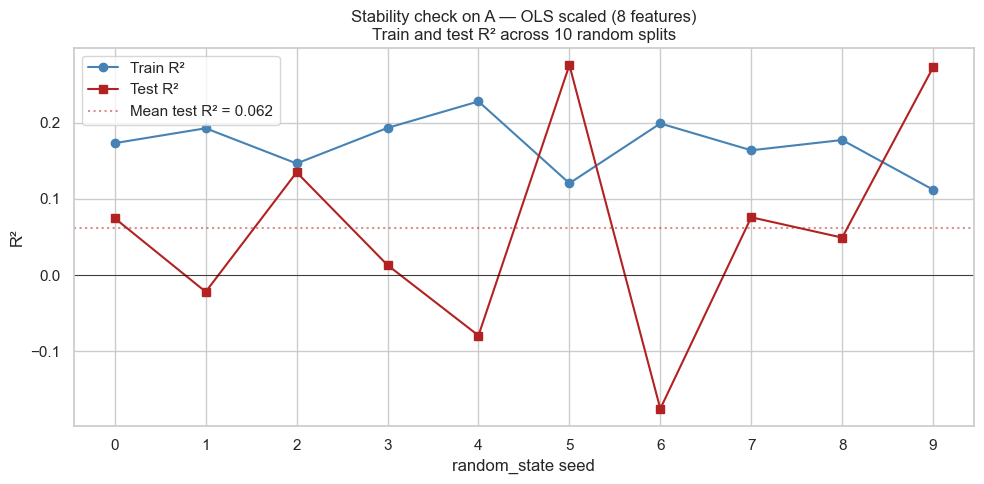

In [36]:
fig, ax = plt.subplots(figsize=(10, 5))
x = stab_df['seed']
ax.plot(x, stab_df['train_r2'], 'o-', label='Train R²', color='steelblue')
ax.plot(x, stab_df['test_r2'], 's-', label='Test R²', color='firebrick')
ax.axhline(test_mean, color='firebrick', linestyle=':', alpha=0.5,
           label=f'Mean test R² = {test_mean:.3f}')
ax.axhline(0, color='black', linewidth=0.5)
ax.set_xlabel('random_state seed')
ax.set_ylabel('R²')
ax.set_title(f'Stability check on {winner_name}\nTrain and test R² across 10 random splits')
ax.legend()
ax.set_xticks(x)
plt.tight_layout()
plt.show()

## 9. Refit the winning OLS for inference
Even if a tree-based model wins, we still refit the best OLS for coefficient interpretation since trees do not give us p-values or confidence intervals. The winning OLS is the one with the highest test R² among Models A and B.

In [37]:
ols_results = [r for r in results if 'OLS' in r['model']]
best_ols = max(ols_results, key=lambda r: r['test_r2'])
best_ols_features = features_full if 'reduced' not in best_ols['model'] else features_reduced

print(f'Best OLS for inference: {best_ols["model"]}')
print(f'Features: {best_ols_features}\n')

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train[best_ols_features]),
    columns=best_ols_features, index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test[best_ols_features]),
    columns=best_ols_features, index=X_test.index
)

X_train_sm = sm.add_constant(X_train_scaled)
X_test_sm = sm.add_constant(X_test_scaled)

ols_model = sm.OLS(y_train, X_train_sm).fit()
print(ols_model.summary())
print(f'\nCondition number: {ols_model.condition_number:.2f}')

Best OLS for inference: A — OLS scaled (8 features)
Features: ['tree_canopy_pct', 'bachelors_pct', 'water_consumption_gpd', 'median_rent', 'absenteeism_pct', 'household_income', 'housing_size_sqft', 'voter_participation_pct']

                             OLS Regression Results                             
Dep. Variable:     log_home_sales_price   R-squared:                       0.131
Model:                              OLS   Adj. R-squared:                  0.111
Method:                   Least Squares   F-statistic:                     6.500
Date:                  Thu, 30 Apr 2026   Prob (F-statistic):           6.76e-08
Time:                          09:45:18   Log-Likelihood:                -190.45
No. Observations:                   355   AIC:                             398.9
Df Residuals:                       346   BIC:                             433.8
Df Model:                             8                                         
Covariance Type:              nonrobust     

## 10. Coefficient interpretation and feature importance
Two complementary views:
1. **Linear coefficients** from the best OLS, on standardized features. Each coefficient is the effect of a 1 SD increase in that feature on log(price).
2. **Tree-based feature importance** from the winning tree model (if applicable), showing which features the trees split on most.

In [38]:
# OLS coefficient table
coef_table = pd.DataFrame({
    'feature': ols_model.params.index,
    'coef_std_units': ols_model.params.values,
    'std_err': ols_model.bse.values,
    'p_value': ols_model.pvalues.values,
    'pct_effect_per_1sd': (np.exp(ols_model.params.values) - 1) * 100,
    'significant_05': ols_model.pvalues.values < 0.05,
}).round(4)
coef_table

,feature,coef_std_units,std_err,p_value,pct_effect_per_1sd,significant_05
0,const,12.9709,0.0222,0.0000,"42,973,632.7910",True
1,tree_canopy_pct,-0.0557,0.0275,0.0435,-5.4186,True
2,bachelors_pct,0.0371,0.0390,0.3430,3.7769,False
3,water_consumption_gpd,0.0577,0.0425,0.1754,5.9347,False
4,median_rent,-0.0076,0.0267,0.7765,-0.7569,False
5,absenteeism_pct,0.0007,0.0411,0.9855,0.0750,False
6,household_income,0.0943,0.0409,0.0216,9.8905,True
7,housing_size_sqft,0.0096,0.0522,0.8548,0.9610,False
8,voter_participation_pct,0.0125,0.0310,0.6868,1.2588,False


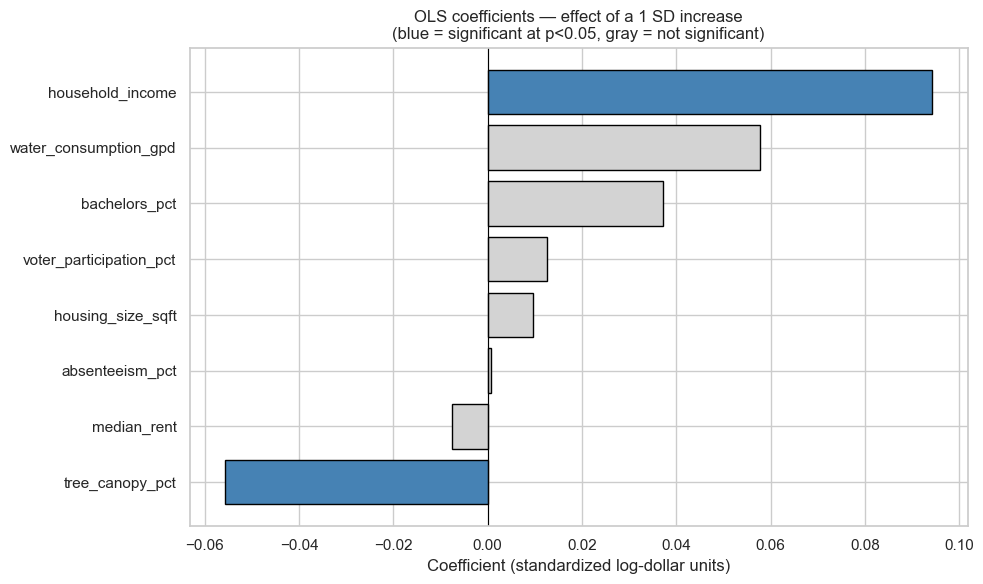

In [39]:
# OLS coefficient bar chart
plot_df = coef_table[coef_table['feature'] != 'const'].copy()
plot_df = plot_df.sort_values('coef_std_units', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['steelblue' if s else 'lightgray' for s in plot_df['significant_05']]
ax.barh(plot_df['feature'], plot_df['coef_std_units'], color=colors, edgecolor='black')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient (standardized log-dollar units)')
ax.set_title('OLS coefficients — effect of a 1 SD increase\n(blue = significant at p<0.05, gray = not significant)')
plt.tight_layout()
plt.show()

In [40]:
# Feature importance for tree models, if applicable
if 'Random Forest' in winner_name or 'Gradient Boosting' in winner_name:
    winner_model = make_winner()
    winner_model.fit(X_train[winner_features], y_train)

    importances = winner_model.feature_importances_
    fi_df = pd.DataFrame({
        'feature': winner_features,
        'importance': importances
    }).sort_values('importance', ascending=True)

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(fi_df['feature'], fi_df['importance'], color='seagreen', edgecolor='black')
    ax.set_xlabel('Feature Importance')
    ax.set_title(f'{winner_name} — Feature Importance')
    plt.tight_layout()
    plt.show()

    print(fi_df.round(4).to_string(index=False))
else:
    print('Winner is a linear model. Coefficient bar chart above shows feature effects.')

Winner is a linear model. Coefficient bar chart above shows feature effects.


## 11. Residual diagnostics
Three checks for whether the winning model's assumptions hold on the test set.

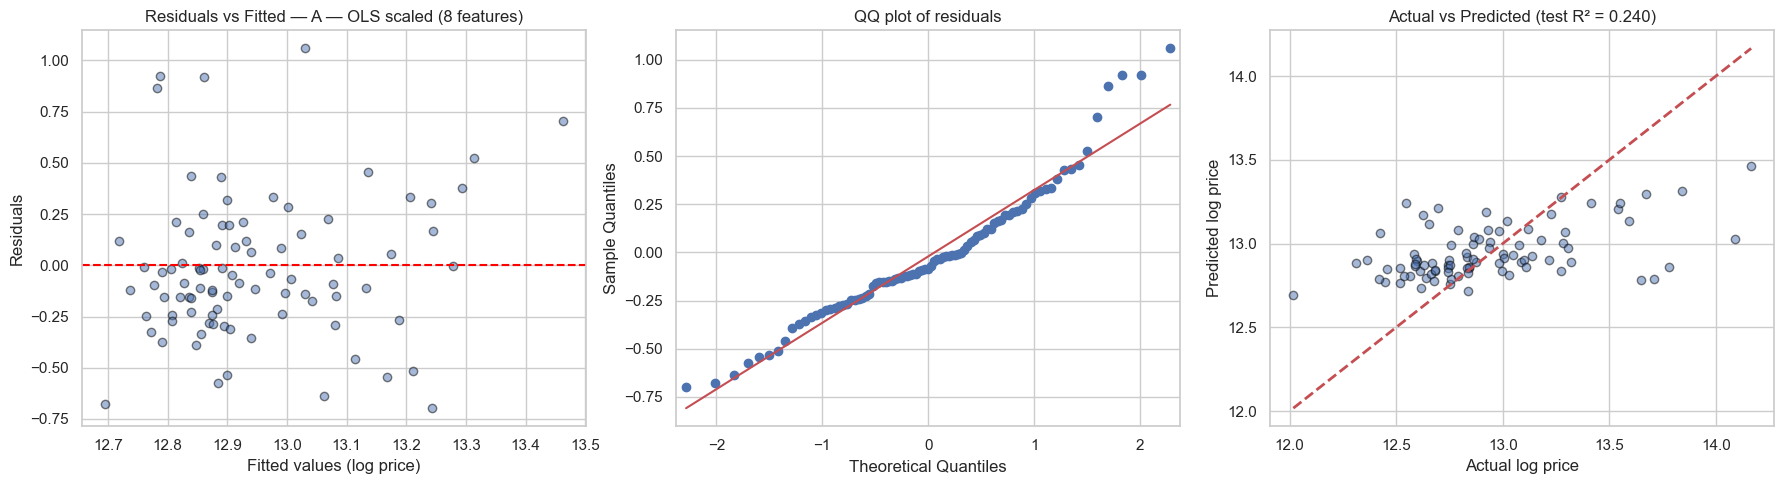

In [41]:
# Use the actual winning model (not just OLS) for residuals
winner_fit = make_winner()
winner_fit.fit(X_train[winner_features], y_train)
y_test_pred = winner_fit.predict(X_test[winner_features])
residuals = y_test - y_test_pred

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(y_test_pred, residuals, alpha=0.5, edgecolor='black')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Fitted values (log price)')
axes[0].set_ylabel('Residuals')
axes[0].set_title(f'Residuals vs Fitted — {winner_name}')

sm.qqplot(residuals, line='s', ax=axes[1])
axes[1].set_title('QQ plot of residuals')

axes[2].scatter(y_test, y_test_pred, alpha=0.5, edgecolor='black')
lo, hi = y_test.min(), y_test.max()
axes[2].plot([lo, hi], [lo, hi], 'r--', linewidth=2)
axes[2].set_xlabel('Actual log price')
axes[2].set_ylabel('Predicted log price')
axes[2].set_title(f'Actual vs Predicted (test R² = {winner["test_r2"]:.3f})')

plt.tight_layout()
plt.show()

## 12. Back-transform to dollar scale

In [42]:
y_test_pred_dollars = np.exp(y_test_pred)
y_test_dollars = np.exp(y_test)

dollar_rmse = np.sqrt(mean_squared_error(y_test_dollars, y_test_pred_dollars))
dollar_mae = np.mean(np.abs(y_test_dollars.values - y_test_pred_dollars))
median_actual = y_test_dollars.median()

print(f'Test RMSE (dollar scale): ${dollar_rmse:,.0f}')
print(f'Test MAE (dollar scale):  ${dollar_mae:,.0f}')
print(f'Median actual test price: ${median_actual:,.0f}')
print(f'Median absolute error as percent of median actual: {dollar_mae / median_actual * 100:.1f}%')

Test RMSE (dollar scale): $194,441
Test MAE (dollar scale):  $124,116
Median actual test price: $376,858
Median absolute error as percent of median actual: 32.9%


In [43]:
pred_df = pd.DataFrame({
    'npa_id': test_npa_ids,
    'actual_price': y_test_dollars.values,
    'predicted_price': y_test_pred_dollars,
    'residual_dollars': y_test_dollars.values - y_test_pred_dollars,
})
pred_df['abs_pct_error'] = (pred_df['residual_dollars'].abs() / pred_df['actual_price'] * 100).round(2)
pred_df = pred_df.sort_values('abs_pct_error').reset_index(drop=True)

print('Best predictions (smallest % error):')
print(pred_df.head(5).to_string(index=False))
print('\nWorst predictions (largest % error):')
print(pred_df.tail(5).to_string(index=False))

Best predictions (smallest % error):
 npa_id  actual_price  predicted_price  residual_dollars  abs_pct_error
    413  582,691.0000     584,001.7969       -1,310.7969         0.2200
     84  344,791.0000     348,149.1821       -3,358.1821         0.9700
     98  375,145.0000     371,021.2053        4,123.7947         1.1000
    389  377,636.0000     382,067.0964       -4,431.0964         1.1700
     21  390,925.0000     396,498.9612       -5,573.9612         1.4300

Worst predictions (largest % error):
 npa_id  actual_price  predicted_price  residual_dollars  abs_pct_error
    151  304,061.0000     523,535.3286     -219,474.3286        72.1800
     58  222,328.0000     394,457.3387     -172,129.3387        77.4200
    122  248,462.0000     470,465.5214     -222,003.5214        89.3500
     83  165,684.0000     326,325.9084     -160,641.9084        96.9600
    184  280,989.0000     564,349.1577     -283,360.1577       100.8400


## 13. Save outputs to database

In [44]:
results_df.to_sql('regression_model_comparison', conn, if_exists='replace', index=False)
pred_df.to_sql('regression_test_predictions', conn, if_exists='replace', index=False)
coef_table.to_sql('regression_final_coefficients', conn, if_exists='replace', index=False)
stab_df.to_sql('regression_stability_check', conn, if_exists='replace', index=False)

for tbl in ['regression_model_comparison', 'regression_test_predictions',
            'regression_final_coefficients', 'regression_stability_check']:
    n = pd.read_sql(f'SELECT COUNT(*) AS n FROM {tbl}', conn)['n'][0]
    print(f'{tbl}: {n} rows saved')

regression_model_comparison: 7 rows saved
regression_test_predictions: 89 rows saved
regression_final_coefficients: 9 rows saved
regression_stability_check: 10 rows saved


In [45]:
conn.close()
print('\nConnection closed. Regression notebook complete.')
print('Next: notebook 04 (classification of displacement_risk).')


Connection closed. Regression notebook complete.
Next: notebook 04 (classification of displacement_risk).


# 14. Apply the Fannie Mae affordability test to predicted vs actual prices
# Uses the same assumptions as notebook 02: 30-year fixed at 7%, 20% down, 36% DTI

In [47]:
# Mortgage payment factor
r = 0.07 / 12
n = 360
monthly_factor = (r * (1 + r) ** n) / ((1 + r) ** n - 1)

# Pull household_income for the test NPAs
test_income = df.loc[X_test.index, 'household_income'].fillna(
    df['household_income'].median()
).values

# Compute affordability ratios for both actual and predicted prices
actual_loan       = y_test_dollars * (1 - 0.20)
predicted_loan    = y_test_pred_dollars * (1 - 0.20)
actual_annual     = actual_loan * monthly_factor * 12
predicted_annual  = predicted_loan * monthly_factor * 12
affordable_annual = test_income * 0.36

actual_at_risk    = (actual_annual > affordable_annual).astype(int)
predicted_at_risk = (predicted_annual > affordable_annual).astype(int)

# Confusion matrix
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
cm = confusion_matrix(actual_at_risk, predicted_at_risk)
print('Predicted-vs-actual displacement classification (test set):')
print(f'\nConfusion matrix:')
print(f'                  Pred Stable  Pred At Risk')
print(f'Actual Stable     {cm[0,0]:>11d}  {cm[0,1]:>12d}')
print(f'Actual At Risk    {cm[1,0]:>11d}  {cm[1,1]:>12d}')
print(f'\nAccuracy: {accuracy_score(actual_at_risk, predicted_at_risk):.3f}')
print(f'\nClassification report:')
print(classification_report(actual_at_risk, predicted_at_risk,
                            target_names=['Stable', 'At Risk']))

Predicted-vs-actual displacement classification (test set):

Confusion matrix:
                  Pred Stable  Pred At Risk
Actual Stable              41            10
Actual At Risk             10            28

Accuracy: 0.775

Classification report:
              precision    recall  f1-score   support

      Stable       0.80      0.80      0.80        51
     At Risk       0.74      0.74      0.74        38

    accuracy                           0.78        89
   macro avg       0.77      0.77      0.77        89
weighted avg       0.78      0.78      0.78        89

